In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from modules.onchain.patterns.ta_patterns import (
    compute_ta_indicators, 
    detect_candlestick_patterns, 
    _generate_signal
)

In [2]:
dates = pd.date_range(end=pd.Timestamp.now(), periods=100, freq='h')
prices = np.linspace(30000, 32000, 100) + np.random.randn(100) * 200

df = pd.DataFrame({
    "time": dates,
    "open": prices - np.random.rand(100)*50,
    "high": prices + np.random.rand(100)*50,
    "low": prices - np.random.rand(100)*50,
    "close": prices,
    "volume": np.random.randint(1000, 5000, 100)
})

In [3]:
df

,time,open,high,low,close,volume
0,2025-11-08 15:58:40.547352,29936.450276,29995.381098,29957.664605,29978.124306,3742
1,2025-11-08 16:58:40.547352,30080.035098,30115.882342,30102.583256,30102.689635,3420
2,2025-11-08 17:58:40.547352,29484.573727,29532.665722,29456.161697,29505.733414,3528
3,2025-11-08 18:58:40.547352,29967.957643,30021.606784,29994.439475,30012.746328,2543
4,2025-11-08 19:58:40.547352,30317.148963,30402.608929,30349.412116,30358.826019,4318
...,...,...,...,...,...,...
95,2025-11-12 14:58:40.547352,31833.892653,31890.532953,31874.061368,31878.134604,4629
96,2025-11-12 15:58:40.547352,31751.356697,31803.105536,31761.770439,31795.414721,3610
97,2025-11-12 16:58:40.547352,31887.738853,31950.124783,31882.396150,31903.902528,3760
98,2025-11-12 17:58:40.547352,31772.610330,31823.743872,31740.052245,31777.963084,4517


In [4]:
df = compute_ta_indicators(df)
df = detect_candlestick_patterns(df)
df.tail(5)

{"timestamp": "2025-11-12 18:58:40,683", "level": "INFO", "message": "Computed TA indicators successfully", "module": "ta_patterns", "function": "compute_ta_indicators", "line": 95}


{"timestamp": "2025-11-12 18:58:40,692", "level": "INFO", "message": "Detected candlestick patterns successfully", "module": "ta_patterns", "function": "detect_candlestick_patterns", "line": 114}


,time,open,high,low,close,volume,sma_7,sma_21,ema_8,ema_20,...,atr,bb_upper,bb_middle,bb_lower,obv,volume_pct_change,cdl_engulfing,cdl_harami,cdl_hammer,cdl_shootingstar
95,2025-11-12 14:58:40.547352,31833.892653,31890.532953,31874.061368,31878.134604,4629,31887.742180,31728.199475,31868.642386,31750.817972,...,226.907471,32173.325977,31751.863181,31330.400386,13349.0,190.949089,0,0,0,0
96,2025-11-12 15:58:40.547352,31751.356697,31803.105536,31761.770439,31795.414721,3610,31892.740910,31753.937064,31852.369571,31755.065282,...,219.011521,32168.673347,31768.523552,31368.373757,9739.0,-22.013394,0,0,0,0
97,2025-11-12 16:58:40.547352,31887.738853,31950.124783,31882.396150,31903.902528,3760,31863.210216,31774.970170,31863.821340,31769.240257,...,214.418560,32124.236767,31801.586388,31478.936009,13499.0,4.155125,0,0,0,0
98,2025-11-12 17:58:40.547352,31772.610330,31823.743872,31740.052245,31777.963084,4517,31850.475941,31800.461469,31844.741727,31770.071003,...,210.806540,32120.894765,31809.908924,31498.923083,8982.0,20.132979,0,0,0,0
99,2025-11-12 18:58:40.547352,31564.095745,31611.473628,31584.347456,31599.066613,1764,31826.409817,31799.868814,31790.147257,31753.784870,...,209.578618,32124.676641,31806.981368,31489.286095,7218.0,-60.947532,0,0,0,0


In [5]:
last_row = df.iloc[-1]
rsi = last_row["rsi"]
macd_hist = last_row["macd_hist"]

In [6]:
pattern = "none"
pattern_direction = None

if last_row["cdl_engulfing"] != 0:
    pattern = "bullish_engulfing" if last_row["cdl_engulfing"] > 0 else "bearish_engulfing"
    pattern_direction = "bullish" if last_row["cdl_engulfing"] > 0 else "bearish"
elif last_row["cdl_harami"] != 0:
    pattern = "bullish_harami" if last_row["cdl_harami"] > 0 else "bearish_harami"
    pattern_direction = "bullish" if last_row["cdl_harami"] > 0 else "bearish"
elif last_row["cdl_hammer"] != 0:
    pattern = "hammer"
    pattern_direction = "bullish"
elif last_row["cdl_shootingstar"] != 0:
    pattern = "shooting_star"
    pattern_direction = "bearish"

print(last_row)
print(pattern)
print(pattern_direction)

time                 2025-11-12 18:58:40.547352
open                               31564.095745
high                               31611.473628
low                                31584.347456
close                              31599.066613
volume                                     1764
sma_7                              31826.409817
sma_21                             31799.868814
ema_8                              31790.147257
ema_20                              31753.78487
rsi                                   47.917802
macd                                  87.523036
macd_signal                          129.648464
macd_hist                            -42.125428
atr                                  209.578618
bb_upper                           32124.676641
bb_middle                          31806.981368
bb_lower                           31489.286095
obv                                      7218.0
volume_pct_change                    -60.947532
cdl_engulfing                           

In [7]:
signal, explanation = _generate_signal(rsi, macd_hist, pattern, pattern_direction)
print("Signal:", signal)
print("Explanation:", explanation)

Signal: bearish
Explanation: MACD histogram < 0 suggests bearish bias


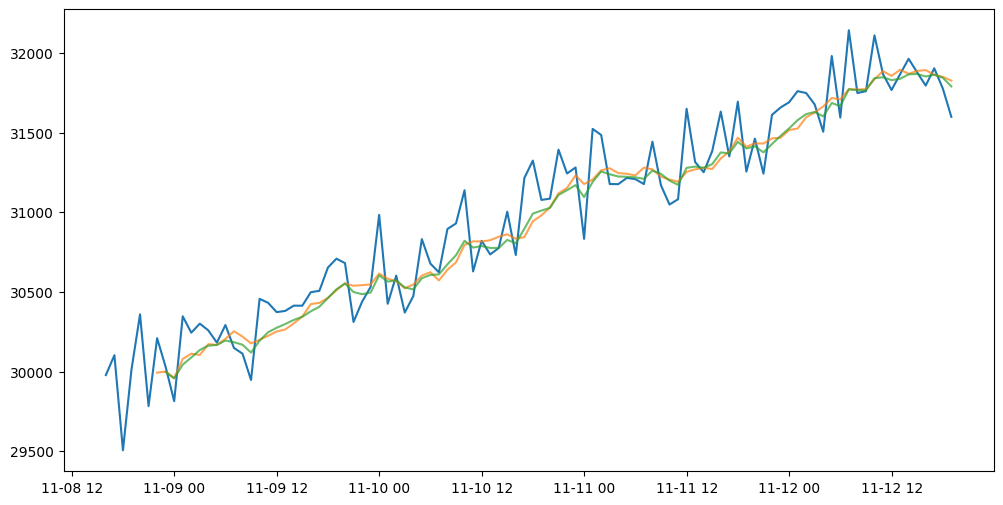

In [8]:
plt.figure(figsize=(12,6))
plt.plot(df["time"], df["close"], label="Close", lw=1.5)
plt.plot(df["time"], df["sma_7"], label="SMA 7", alpha=0.7)
plt.plot(df["time"], df["ema_8"], label="EMA 8", alpha=0.7)

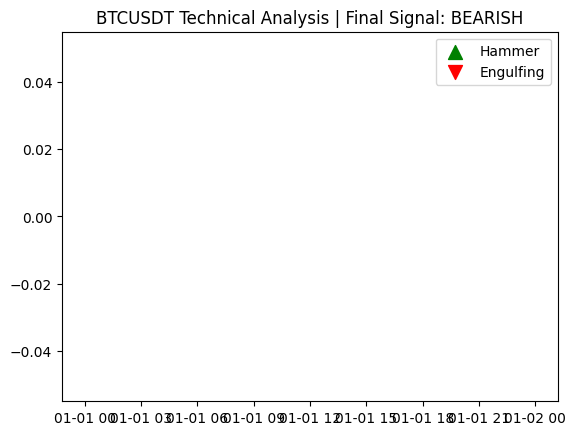

In [9]:
plt.scatter(df.loc[df["cdl_hammer"] != 0, "time"], df.loc[df["cdl_hammer"] != 0, "close"],
            color="green", label="Hammer", marker="^", s=100)
plt.scatter(df.loc[df["cdl_engulfing"] != 0, "time"], df.loc[df["cdl_engulfing"] != 0, "close"],
            color="red", label="Engulfing", marker="v", s=100)

plt.legend()
plt.title(f"BTCUSDT Technical Analysis | Final Signal: {signal.upper()}")
plt.show()